In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import gc
from pathlib import Path
from define_data_and_variables import opes_config, opes_hash, data, version

In [2]:
base_dir = Path.cwd()
base_path = base_dir / ".." / ".." / ".." / ".." / "data"

print(data["dn"].lower())
data_name = rf"$A_{{{data["dn"][:3]}}}$"
ylim_max = 0.4
bin_range = (1660, 1730)
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"

biw_dec


In [3]:
base_dir = Path.cwd()
dir = base_dir / f"output/{data["dn"]}/{version}"
output_dir = dir / f"{opes_hash}"
print(output_dir)
hmc_config = opes_config["hmcc"]

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\OPES_partial_likelihood\output\biw_dec\0\31559a3e78


In [4]:
color_list = plt.cm.viridis(np.linspace(0, 1, np.min((hmc_config["nch"], 5))))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

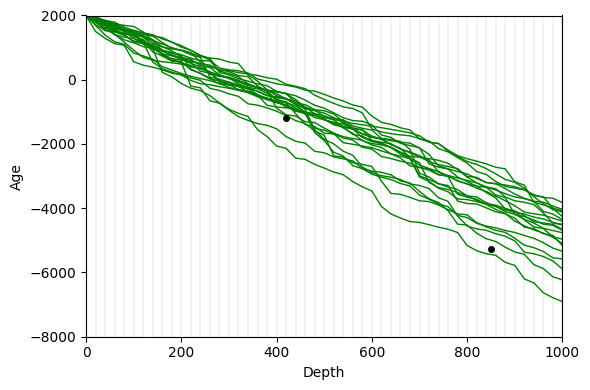

In [5]:

cumulative_sums = np.cumsum(hmc_config["sp"], axis=1) * data["dc"]
zeros = np.zeros((*hmc_config["sp"].shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)

model_ages = data["th"] - age_offsets

# Starting points
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(hmc_config["sp"])
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(np.min(data["d18ort"]), np.max(data["d18ort"]))
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
# plt.savefig(f"{dir}/sp_age_depth.jpg")
plt.show()

In [6]:
base_dir = Path.cwd()
df = np.load(f"{output_dir}/df.npy", mmap_mode = "r")

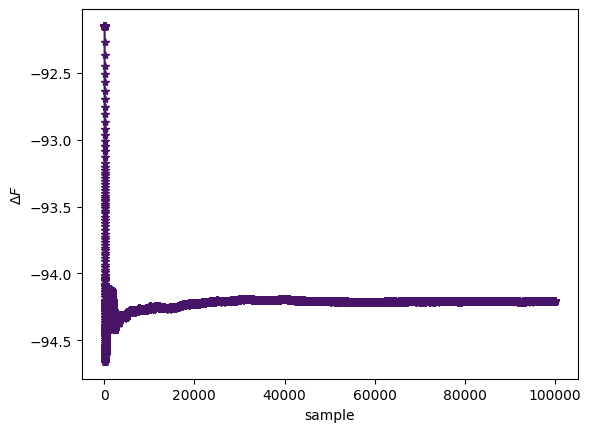

In [7]:
fig, ax = plt.subplots()
ind = -1
chain = 0
x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
sample_delta_F = np.squeeze(df[chain, :, -1])
ax.plot(x[10:], sample_delta_F[10:], '*-', color = temp_colors[1])
plt.xlabel(f"sample")
plt.ylabel(r"$\Delta F$")
# plt.savefig(f"{output_dir}/df_{ind}.jpg")
plt.show()


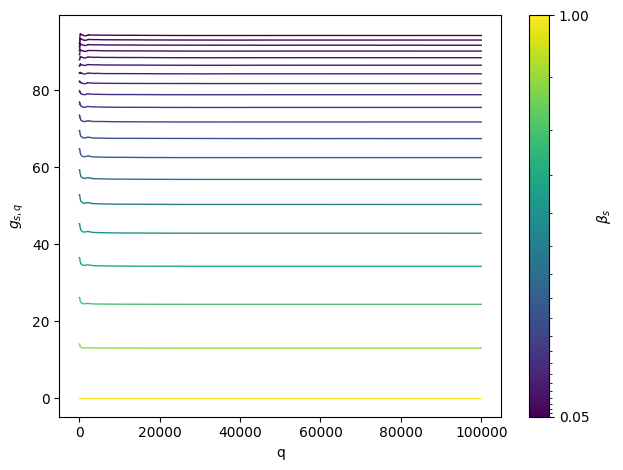

In [8]:
import matplotlib as mpl
fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=min(opes_config['bs']), vmax=max(opes_config['bs']))
cmap = plt.cm.viridis

for k in range(opes_config["nt"]):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:], -sample_delta_F[:], '-', linewidth = 1, color=cmap(norm(opes_config['bs'][k])), label = fr"$\beta_{{{k}}} = $" + f"{opes_config['bs'][k]:.2f}")

plt.xlabel(f"q")
plt.ylabel(r"$g_{s, q}$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\beta_s$")
ticks = [min(opes_config["bs"]), max(opes_config["bs"])]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_minor_locator(
    plt.FixedLocator(opes_config["bs"])
)

plt.tight_layout()
# plt.savefig(f"{output_dir}/gs.jpg")
plt.show()


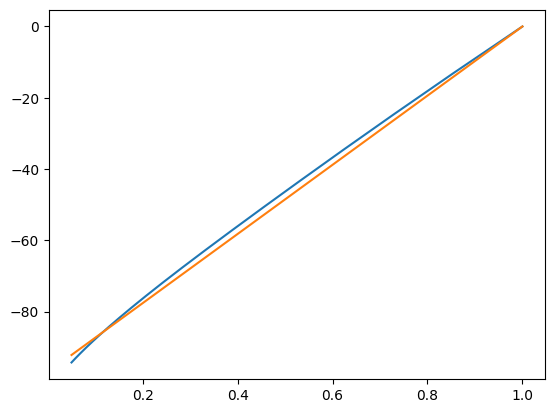

In [9]:
plt.figure()
plt.plot(opes_config["bs"], df[0, 999, :])
plt.plot(opes_config["bs"], opes_config["df"])
plt.show()

In [10]:
del df
gc.collect()

7065

In [11]:
cutout = 10000
bias_values = np.load(f"{output_dir}/bias.npy", mmap_mode='r')[:, cutout:]
energy_values = np.load(f"{output_dir}/energy.npy", mmap_mode='r')[:, cutout:]


In [12]:
neff = np.sum(np.exp(bias_values), axis = 1)**2 / np.sum(np.exp(bias_values)**2, axis = 1)
print(neff)

[15071.51781942 15050.8787979  15121.35152622 15187.92856384
 15267.80967192 15574.40335219 15226.54207848 15697.78285001
 15932.64972201 15294.33252676 15085.95762151 15000.83085931
 15364.39025772 14706.60462814 14280.83792298 15374.16455657
 16368.22749595 14807.31087976 15466.39810805 15378.85182135]


In [13]:
print(np.sum(neff))

305258.77106008644


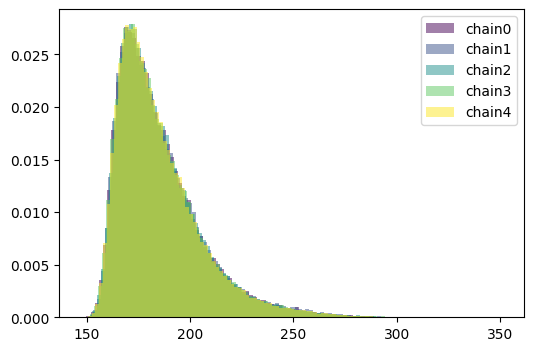

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(np.min((hmc_config["nch"], 5))):
    ax.hist(energy_values[i, cutout:], color = color_list[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
plt.legend()
# plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

In [15]:
print(np.min(energy_values))
print(np.max(bias_values))

146.77445492154112
2.791605322818484


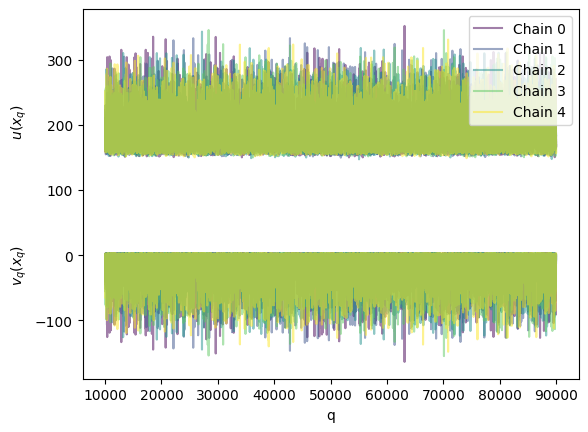

In [16]:
plt.figure()
for i in range(np.min((hmc_config["nch"], 5))):
    plt.plot(np.linspace(cutout, len(bias_values[0, :] + cutout), len(bias_values[i, :])), bias_values[i, :], color = color_list[i], alpha = 0.5, label = f"Chain {i}")
    plt.plot(np.linspace(cutout, len(bias_values[0, :] + cutout), len(bias_values[i, :])), energy_values[i, :], color = color_list[i], alpha = 0.5)
plt.xlabel("q")
plt.ylabel(r"$v_q(x_q)$                        $u(x_q)$")
plt.legend()
# plt.savefig(f"{output_dir}/energy_and_bias.jpg")
plt.show()

In [17]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [18]:
print(az.summary(samples))

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    8.537  5.943   0.810   19.646      0.013    0.010  189195.0  432026.0   
x[1]    8.603  5.780   0.870   19.452      0.012    0.010  202811.0  443213.0   
x[2]    8.907  6.119   0.859   20.435      0.014    0.011  190685.0  432618.0   
x[3]    8.310  5.831   0.845   18.998      0.013    0.012  204544.0  449168.0   
x[4]   10.033  7.577   0.799   24.186      0.018    0.018  177954.0  324625.0   
x[5]    9.377  7.050   0.762   22.786      0.016    0.015  186156.0  372359.0   
x[6]    8.871  6.463   0.779   20.875      0.014    0.012  192219.0  431192.0   
x[7]    8.731  6.365   0.762   20.759      0.014    0.012  200289.0  443854.0   
x[8]    9.211  6.754   0.759   21.975      0.015    0.013  186070.0  388657.0   
x[9]    9.237  6.766   0.794   22.008      0.015    0.013  189049.0  388569.0   
x[10]   8.917  6.508   0.782   21.096      0.014    0.013  198024.0  410589.0   
x[11]   8.026  5.639   0.808

In [19]:
resampled_samples = []
weights = np.exp(bias_values)
for i in range(hmc_config["nch"]):
    weights_i = weights[i, :] / sum(weights[i, :])

    indices = np.random.choice(
        np.arange(0, len(weights_i)),
        size=10000,
        replace=True,
        p=weights_i,
    )
    resampled_samples.append(samples[i, indices, :])
    print(f"Chain {i} done resampling")

resampled_samples = np.array(resampled_samples)

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 5 done resampling
Chain 6 done resampling
Chain 7 done resampling
Chain 8 done resampling
Chain 9 done resampling
Chain 10 done resampling
Chain 11 done resampling
Chain 12 done resampling
Chain 13 done resampling
Chain 14 done resampling
Chain 15 done resampling
Chain 16 done resampling
Chain 17 done resampling
Chain 18 done resampling
Chain 19 done resampling


In [20]:
print(az.summary(resampled_samples))

         mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
x[0]    8.486   5.866   0.865   19.402      0.013    0.011  198848.0   
x[1]    8.723   5.429   1.018   18.931      0.012    0.010  197355.0   
x[2]    9.472   5.994   0.986   20.914      0.013    0.010  199056.0   
x[3]    7.468   4.783   0.842   16.623      0.011    0.010  197479.0   
x[4]    9.591   6.854   0.853   21.917      0.015    0.020  199389.0   
x[5]    9.141   6.396   0.738   21.974      0.014    0.015  199632.0   
x[6]    9.060   5.955   0.806   19.715      0.013    0.013  199623.0   
x[7]    8.712   5.880   0.760   19.852      0.013    0.013  197914.0   
x[8]   10.157   6.880   0.848   23.078      0.015    0.015  199518.0   
x[9]   10.014   6.792   0.964   22.749      0.015    0.015  198181.0   
x[10]   9.064   6.241   0.945   20.803      0.014    0.015  199342.0   
x[11]   6.599   3.920   0.915   13.847      0.009    0.009  197525.0   
x[12]  13.977   6.054   3.588   25.408      0.014    0.010  2002

In [21]:
chain = 0
index = 38
interesting_depth = index * data["dc"]

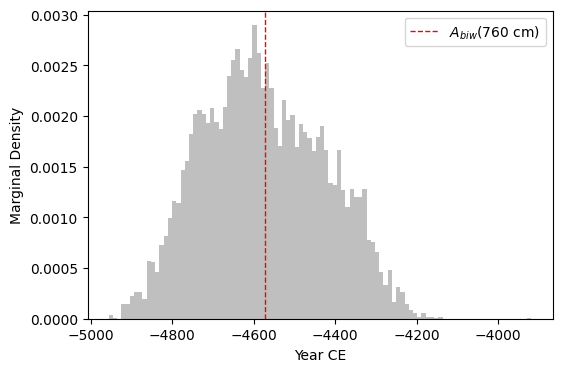

In [22]:
CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[chain][:, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density=True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

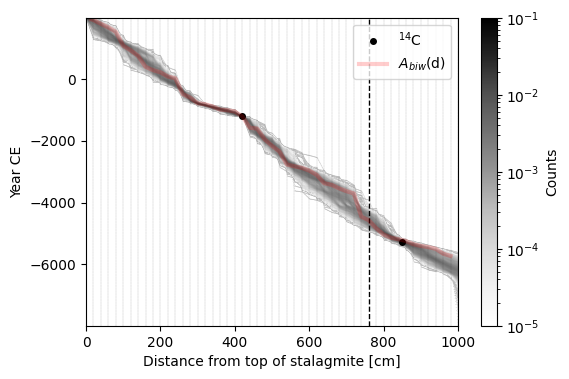

In [23]:
from matplotlib import colors

X = resampled_samples[chain].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if np.max(data["d18ort"]) - np.min(data["d18ort"]) < 2000 else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = data["H"] / 1000
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for j in range(Z):
    C[j, :], _ = np.histogram(A[j, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    linewidth = 0.1 if i != index else 1
    ax.axvline(x=c, color='k', linestyle='--', linewidth = linewidth)


ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["d18od"], data["d18ota"], color = "red", linewidth=3, alpha = 0.2, label = f"{data_name}(d)")

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Counts")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/ad_samples_chain_{chain}.jpg")
plt.show()